Project

In his project, we analyze the Diamonds dataset. The data set contains 53,940 attributes of diamonds with different characteristics. Each diamond is descibred by numerical and categorical variables such as carat, cut, color, clarity, depth, table, dimensions (x, y, z) and price. 


The goal of the analysis is to explore the data, understand the relationships between variables, and apply machine learning models for both clasification and regression tasks.
    

In [206]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, precision_score, f1_score, classification_report, recall_score, mean_squared_error
from sklearn import metrics ,tree
from sklearn.ensemble  import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, KFold


Data analysis

Exploratory Data Analysis is an important step before building machine learning models. It helps us understand:

1. The distribution of numerical variables

2. The relationship beteen variables

3. The presence of outliers

4. Corellations between features


For example, scatter plots help us see the relationship between carat and price. Histograms show the distribution of variables like depth and table. A correlation heatmap helps identify which numerical features are strongly related to each other.

From the analysis, we observe that carat has a strong positive relationship with price. This means that as the weight of the diamond increases, the price also increases.

In [207]:
data = pd.read_csv(r"C:\Users\user\Downloads\archive (10)\diamonds.csv")

In [208]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [209]:
data.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [210]:
data.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Feature Engineering: Creation of a New Variable

In this project, a new feature called data_table_ratio.
    
Feature engineering is the process of creating new variables from existing ones in order to:

Improve model performance

Capture hidden relationships between variables

Provide additional information to the model

Instead of using depth and table separately, the ratio between them may better describe the geometric proportions of the diamond.

Ratios often help machine learning models understand relative relationships instead of absolute values.

In [211]:
data["data_table_ration"] = data["depth"]/data["table"]

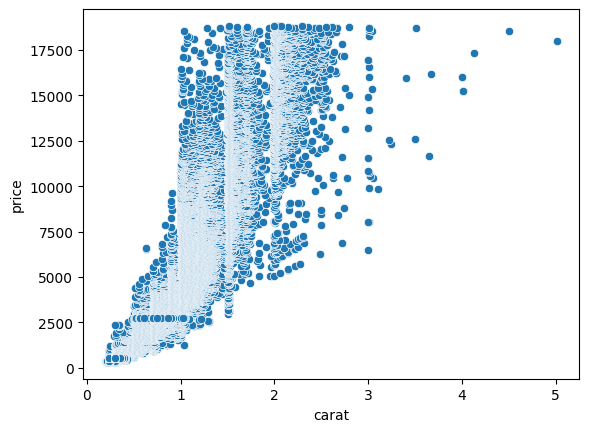

In [212]:
sns.scatterplot(x="carat", y= "price", data=data)
plt.show()

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'carat'}>,
        <Axes: title={'center': 'depth'}>],
       [<Axes: title={'center': 'table'}>,
        <Axes: title={'center': 'price'}>, <Axes: title={'center': 'x'}>],
       [<Axes: title={'center': 'y'}>, <Axes: title={'center': 'z'}>,
        <Axes: title={'center': 'data_table_ration'}>]], dtype=object)

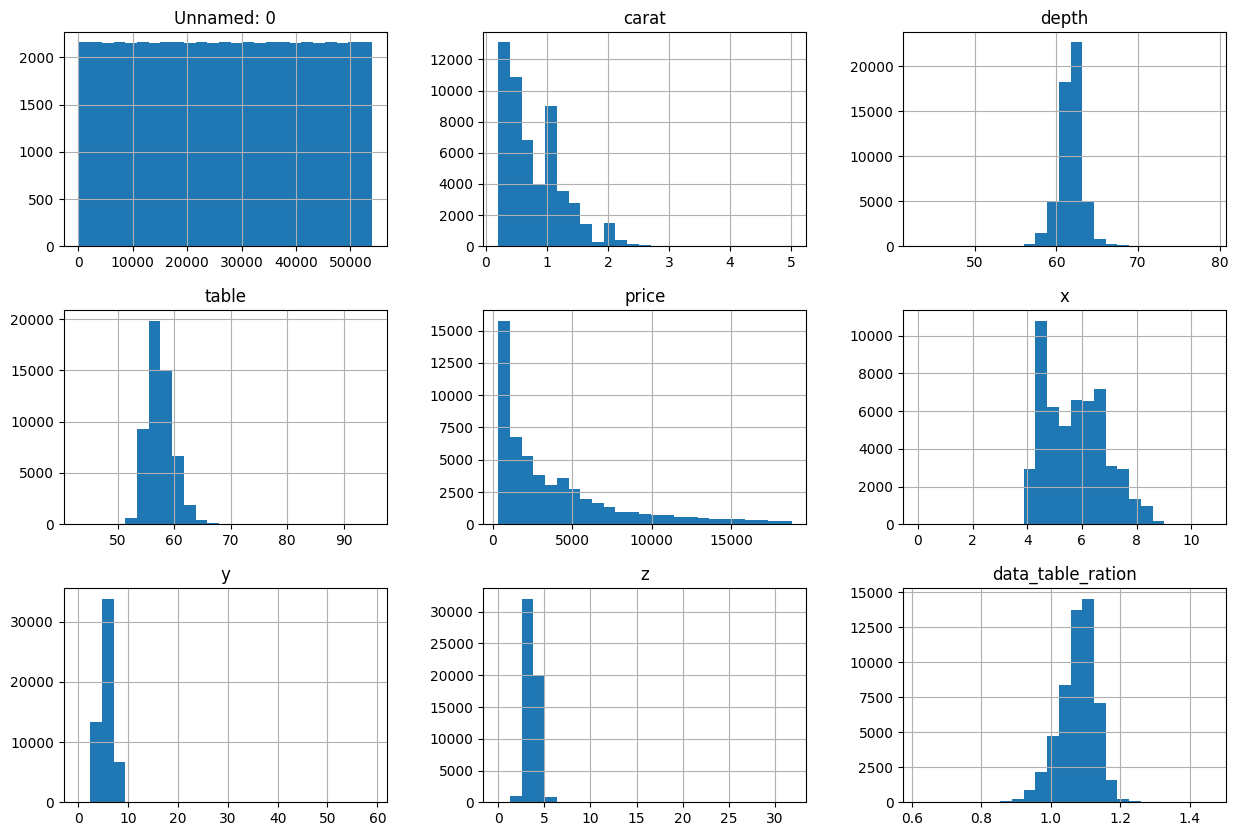

In [213]:
data.hist(bins=25, figsize=(15,10))

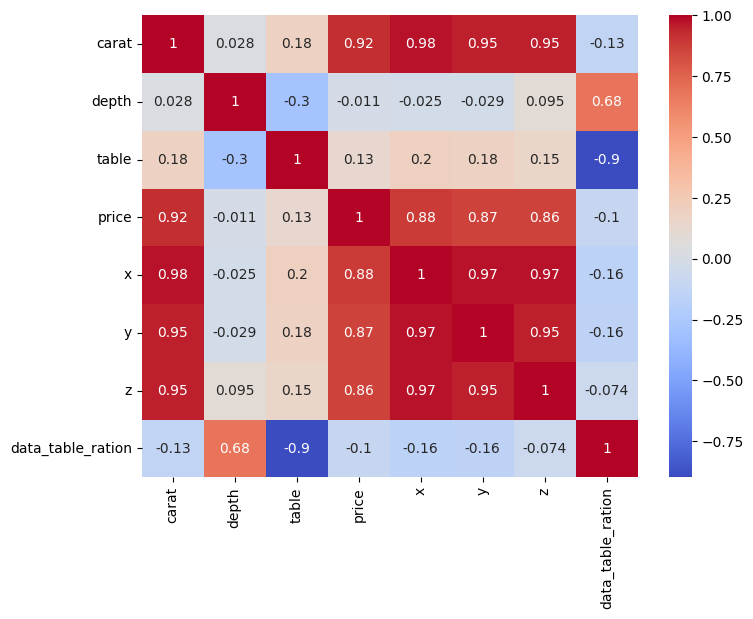

In [214]:
data=data.drop("Unnamed: 0", axis=1)
corr = data.corr(numeric_only=True)

plt.figure(figsize=(8, 6))  # Πλάτος, Ύψος
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

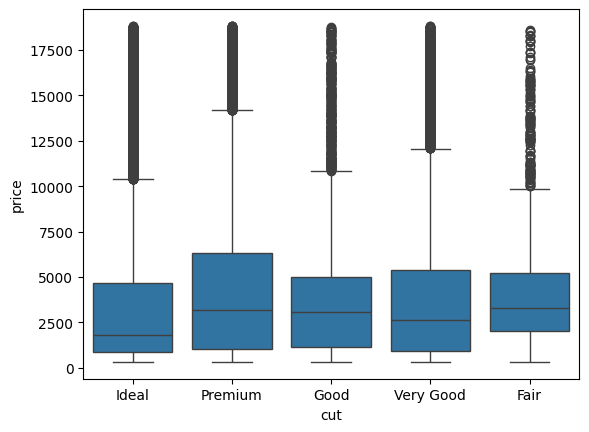

In [215]:
sns.boxplot(x="cut", y="price", data=data)
plt.show()

What does this do;
This command:
1.Selects the cut column
2.Counts how many times each category appears
3.Returns the frequency of each class


In [216]:
cut_diamond = data["cut"].value_counts()
cut_diamond

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

This splits the dataset into groups based on the values of the cut variable.

Each unique cut category becomes a separate group.
    
This calculates the average (mean) value of each selected feature within each cut category.

So, for each cut type, we compute:

Average carat

Average depth

Average price

Average dimensions (x, y, z)

Average data_table_ratio



In [217]:
Catigorical_cut_diamond = data.groupby("cut")[["carat","depth","price","x","y","z","data_table_ration"]].mean()
Catigorical_cut_diamond

,carat,depth,price,x,y,z,data_table_ration
cut,,,,,,,
Fair,1.046137,64.041677,4358.757764,6.246894,6.182652,3.982770,1.091054
Good,0.849185,62.365879,3928.864452,5.838785,5.850744,3.639507,1.065983
Ideal,0.702837,61.709401,3457.541970,5.507451,5.520080,3.401448,1.103530
Premium,0.891955,61.264673,4584.257704,5.973887,5.944879,3.647124,1.043670
Very Good,0.806381,61.818275,3981.759891,5.740696,5.770026,3.559801,1.068389


Encoding Categorical Variables

Machine learning algorithms cannot work directly with text (categorical variables). Therefore, we use Label Encoding to transform categorical variables (cut, color, clarity) into numerical form.

In [218]:
encode_cut = LabelEncoder()
encode_color = LabelEncoder()
encode_clarity = LabelEncoder()


In [219]:
data["cut"] = encode_cut.fit_transform(data["cut"])
data["color"] = encode_color.fit_transform(data["color"])
data["clarity"] = encode_clarity.fit_transform(data["clarity"])

Feature = data.drop(["cut"], axis = 1)
target = data["cut"]

Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, and the testing set is used to evaluate its performance. This helps prevent overfitting and ensures that the model generalizes well to unseen data.

In [234]:
X_train, X_test, y_train, y_test = train_test_split(Feature, target, test_size = 0.3, random_state=19)

In [235]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(37758, 10)
(37758,)
(16182, 10)
(16182,)


A Decision Tree is a supervised learning algorithm that splits the data into smaller subsets based on feature values. 
It uses criteria such as entropy to measure the quality of splits.

Decision Trees are easy to interpret and visualize, but they can overfit if not properly controlled.

In [222]:
dtree = tree.DecisionTreeClassifier(criterion ="entropy")
dtree.fit(X_train, y_train)
y_pred = dtree.predict(X_test)



In [223]:
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average ="macro")
f1 = f1_score(y_test, y_pred, average = "macro")

print(precision)
print(recall)
print(f1)


0.7057686926693144
0.7045004647023768
0.7050927987500029


Feature Scaling


Some algorithms perform better when features are scaled. We use MinMaxScaler to transform the features into a range between 0 and 1. Scaling ensures that all variables contribute equally to the model.

In [224]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(Feature)

Cross-Validation and Stratified K-Fold (SKF)


In order to evaluate the performance of the model more reliably, we use Cross-Validation.

What is Cross-Validation?

Cross-validation is a resampling technique used to evaluate machine learning models. Instead of splitting the dataset only once into training and testing sets, the data is divided into multiple parts (folds).

The model is trained and tested multiple times, each time using a different fold as the test set and the remaining folds as the training set.

This method:

Reduces overfitting

Gives a more stable and reliable performance estimate

Uses all data for both training and testing



K-Fold Cross-Validation
In K-Fold Cross-Validation, the dataset is divided into K equal parts (folds).

For example, if K = 5:

The model trains on 4 folds

Tests on the remaining 1 fold

This process repeats 5 times

The final performance is the average of the 5 results.

In [225]:
Models = RandomForestClassifier(random_state = 21, n_estimators = 50)

skf = StratifiedKFold(n_splits=5,
                     shuffle = True,
                     random_state =21
                     )


scoring = ["accuracy", 
           "precision_macro",
           "recall_macro",
           "f1_macro"
          ]
scores = cross_validate(
    Models,
    Feature,
    target,
    cv=skf,
    scoring = scoring
)

In [226]:

print("Precision :", scores["test_precision_macro"].round(2).mean())
print("Recall:", scores["test_recall_macro"].round(2).mean())
print("F1:", scores["test_f1_macro"].round(2).mean())

Precision : 0.784
Recall: 0.7619999999999999
F1: 0.77


X = data.drop(columns=["price"])

drop(columns=["price"]) removes the column price. X contains all the input features (independent variables)

In [230]:

X = data.drop( columns = ["price"])
y1 =data["price"]

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)


 K-Fold
1)The dataset is divided into 5 parts (folds).

2)The model trains on 4 folds.

3)Tests on 1 fold.
    
4)This repeats 5 times.
    
5)Final score = average of 5 results.

Parameters:
n_splits=5 → 5 folds
    
shuffle=True → data is shuffled before splitting
    
random_state=21 → reproducible split

In theory:
Cross-validation gives a more reliable evaluation of model performance

In [231]:
Model1 = RandomForestRegressor(random_state = 21, n_estimators = 50)

skf = KFold(n_splits=5,
          shuffle=True,
        random_state=21)

scores1 = cross_validate(
    Model1,
    X,
    y1,
    cv=skf,
    scoring = "neg_mean_squared_error"
)

In [232]:
mse1 = -scores1["test_score"]
print(mse1.mean().round(2))

303638.09


LinearRegression()

This creates a Linear Regression model.
What is Linear Regression?

It tries to fit a line:
y=b0+b1x1+b2x2+...

It assumes a linear relationship

In theory:
It finds the best straight-line equation to predict price.

In [240]:
model1 = LinearRegression()

kf = KFold(
    n_splits = 5,
    shuffle = True,
)

scores = cross_validate(
    model1,
    X1,
    y,
    cv = kf,
    scoring = "neg_mean_squared_error"
)

mse =  -scores["test_score"]

print(mse.mean().round(2))

1293191.7
